# 📘 Session 12: Advanced Seaborn and Statistical Visualization
### Duration: ~2.5 Hours

---

**Topics Covered:**
1. Seaborn Architecture — Figure-Level vs Axes-Level Functions
2. Distribution Plots — KDE, ECDF, Violin, Rug
3. Categorical Plots — Strip, Swarm, Count, Point, Violin
4. Regression & Relationship Plots
5. Multi-Panel Grids — FacetGrid and PairGrid
6. Styling, Palettes & Publication-Ready Figures

---

**Why This Session Matters for Data Science:**
- **Exploratory Data Analysis (EDA)** relies on fast, informative plots — Seaborn is built for this
- **Statistical insight** — Seaborn embeds statistics (confidence intervals, regression fits, KDE) directly into plots
- **Feature understanding** — distribution and categorical plots reveal feature behavior before modeling
- **Communication** — polished Seaborn figures are presentation-ready with minimal effort
- **Speed** — one-line plots that would take 20+ lines in Matplotlib

> Session 11 introduced Matplotlib and Seaborn basics. This session goes deep into Seaborn's statistical plotting engine — the toolkit you'll reach for daily during EDA.

---
## 1. Seaborn Architecture — Figure-Level vs Axes-Level Functions

Understanding this distinction is key to using Seaborn effectively. It determines how you create, customize, and compose plots.

### The Two Interfaces

| Aspect | Axes-Level | Figure-Level |
|--------|-----------|--------------|
| **Returns** | Matplotlib `Axes` object | Seaborn `FacetGrid` / `JointGrid` / `PairGrid` |
| **Integration** | Fits into existing `fig, ax` layouts | Creates its own figure |
| **Subplots** | Manual with `plt.subplots()` | Automatic via `col`, `row` parameters |
| **Customization** | Direct `ax.set_*()` methods | `.set()`, `.set_axis_labels()`, `.set_titles()` |
| **Size control** | `figsize` on figure | `height` and `aspect` parameters |

### Function Families

| Module | Figure-Level | Axes-Level Functions |
|--------|-------------|---------------------|
| **Relational** | `relplot()` | `scatterplot()`, `lineplot()` |
| **Distribution** | `displot()` | `histplot()`, `kdeplot()`, `ecdfplot()`, `rugplot()` |
| **Categorical** | `catplot()` | `stripplot()`, `swarmplot()`, `boxplot()`, `violinplot()`, `barplot()`, `countplot()`, `pointplot()` |
| **Regression** | `lmplot()` | `regplot()`, `residplot()` |
| **Matrix** | — | `heatmap()`, `clustermap()` |
| **Multi-plot** | `jointplot()`, `pairplot()` | — |

### When to Use Which

| Scenario | Use | Why |
|----------|-----|-----|
| Quick single plot inside `plt.subplots()` | **Axes-level** | Fits into your existing layout |
| Faceted plots (split by category) | **Figure-level** | Built-in `col`/`row` splitting |
| Dashboard with mixed plot types | **Axes-level** | Each subplot can be different |
| Stand-alone statistical figure | **Figure-level** | Cleaner, auto-sized |

> ⚠️ **Special Case — Mixing interfaces**: You can customize figure-level plots with Matplotlib after creation via `.fig` and `.axes` attributes, but you cannot embed a figure-level plot into an existing `plt.subplots()` grid.

> **Data Science relevance**: EDA sessions typically use figure-level functions for speed. Final reports use axes-level for precise layout control.

In [19]:
# --- Setup and datasets ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Load built-in datasets used throughout this session
tips = sns.load_dataset('tips')
penguins = sns.load_dataset('penguins').dropna()
iris = sns.load_dataset('iris')

print("Datasets loaded:")
print(f"  tips:     {tips.shape} — restaurant tipping data")
print(f"  penguins: {penguins.shape} — Palmer penguin measurements")
print(f"  iris:     {iris.shape} — classic flower measurements")
print()
print("Tips sample:")
print(tips.head())

Datasets loaded:
  tips:     (244, 7) — restaurant tipping data
  penguins: (333, 7) — Palmer penguin measurements
  iris:     (150, 5) — classic flower measurements

Tips sample:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


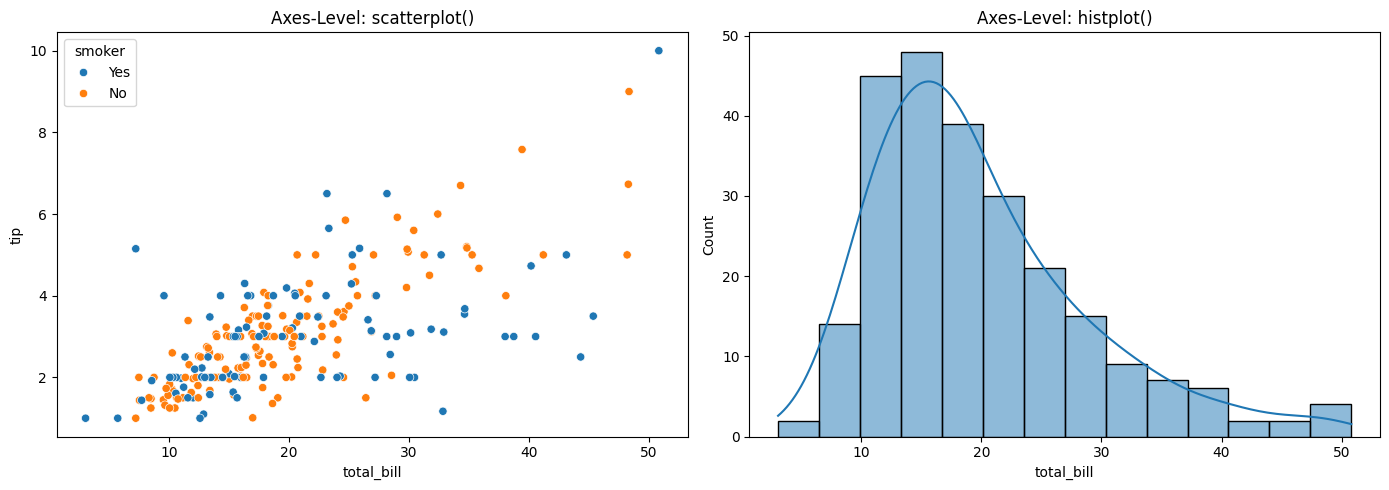

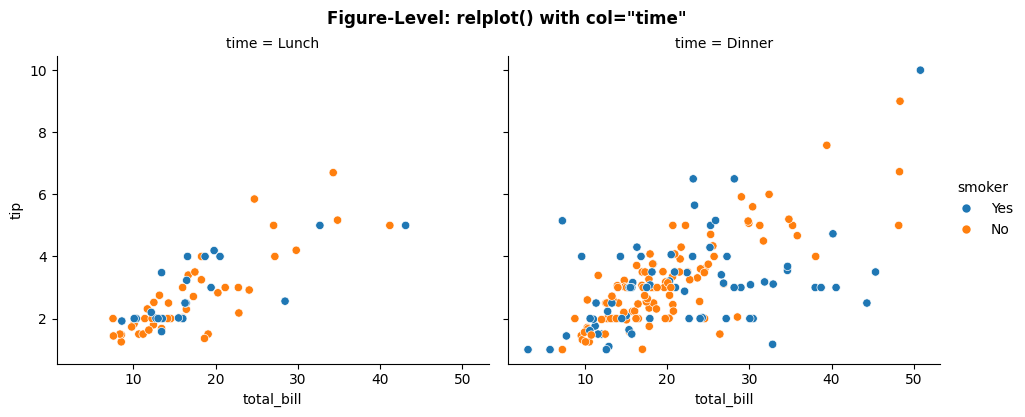

Figure-level relplot returned: <class 'seaborn.axisgrid.FacetGrid'>
Access the figure:  g.fig
Access the axes:    g.axes


In [3]:
# --- Figure-level vs axes-level comparison ---

# AXES-LEVEL: fits into plt.subplots() — returns an Axes object
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=tips, x='total_bill', y='tip', hue='smoker', ax=axes[0])
axes[0].set_title('Axes-Level: scatterplot()')

sns.histplot(data=tips, x='total_bill', kde=True, ax=axes[1])
axes[1].set_title('Axes-Level: histplot()')

plt.tight_layout()
plt.show()

# FIGURE-LEVEL: creates its own figure — returns a FacetGrid
g = sns.relplot(data=tips, x='total_bill', y='tip', hue='smoker',
                col='time', kind='scatter', height=4, aspect=1.2)
g.fig.suptitle('Figure-Level: relplot() with col="time"', y=1.03, fontweight='bold')
plt.show()

print("Figure-level relplot returned:", type(g))
print("Access the figure:  g.fig")
print("Access the axes:    g.axes")

---
## 2. Distribution Plots — Understanding Your Data's Shape

Distribution plots answer: *"How is this variable spread out?"* — the first question in any EDA.

### Distribution Functions

| Function | What It Shows | Best For |
|----------|--------------|----------|
| `histplot()` | Binned frequency counts | Discrete or continuous distributions |
| `kdeplot()` | Smooth density estimate | Continuous distributions, overlays |
| `ecdfplot()` | Cumulative distribution | Percentile questions ("what % is below X?") |
| `rugplot()` | Individual data points on axis | Small datasets, supplement to KDE |
| `displot()` | Figure-level wrapper | Faceted distributions by category |

### Key Parameters

| Parameter | Purpose | Example |
|-----------|---------|---------|
| `kde=True` | Add KDE overlay to histogram | `histplot(data, kde=True)` |
| `stat` | Y-axis statistic | `'count'`, `'density'`, `'probability'`, `'percent'` |
| `hue` | Split by category | `histplot(data, hue='species')` |
| `multiple` | How to handle hue overlap | `'layer'`, `'dodge'`, `'stack'`, `'fill'` |
| `bw_adjust` | KDE bandwidth (smoothness) | `kdeplot(data, bw_adjust=0.5)` — less smooth |
| `cumulative` | Cumulative histogram/KDE | `histplot(data, cumulative=True)` |
| `fill` | Fill under KDE curve | `kdeplot(data, fill=True)` |

> ⚠️ **Special Case — `bw_adjust`**: Lower values (0.3) show more detail but can overfit noise. Higher values (2.0) over-smooth and hide real patterns. Default (1.0) is usually fine.

> **Data Science relevance**: Understanding distributions tells you about skewness, outliers, modality, and which transformations or models are appropriate.

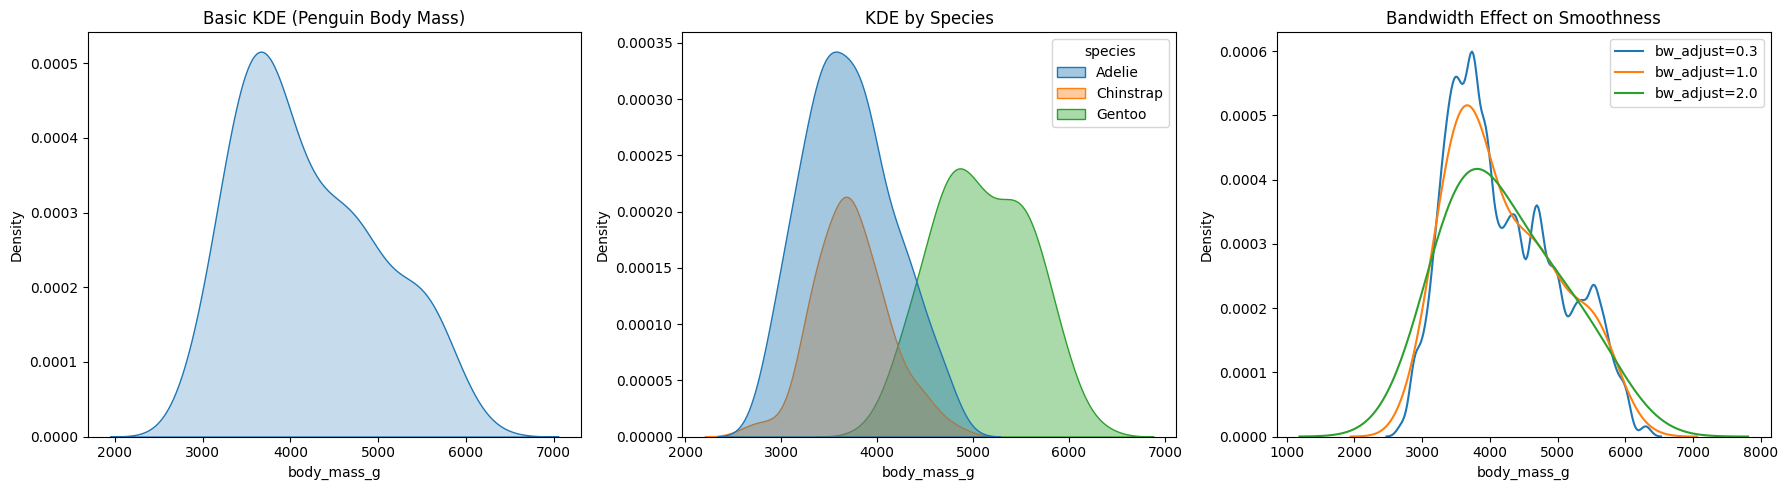

In [4]:
# --- KDE plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Basic KDE with fill
sns.kdeplot(data=penguins, x='body_mass_g', fill=True, ax=axes[0])
axes[0].set_title('Basic KDE (Penguin Body Mass)')

# KDE split by species
sns.kdeplot(data=penguins, x='body_mass_g', hue='species', fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title('KDE by Species')

# Bandwidth comparison
for bw in [0.3, 1.0, 2.0]:
    sns.kdeplot(data=penguins, x='body_mass_g', bw_adjust=bw,
                label=f'bw_adjust={bw}', ax=axes[2])
axes[2].set_title('Bandwidth Effect on Smoothness')
axes[2].legend()

plt.tight_layout()
plt.show()

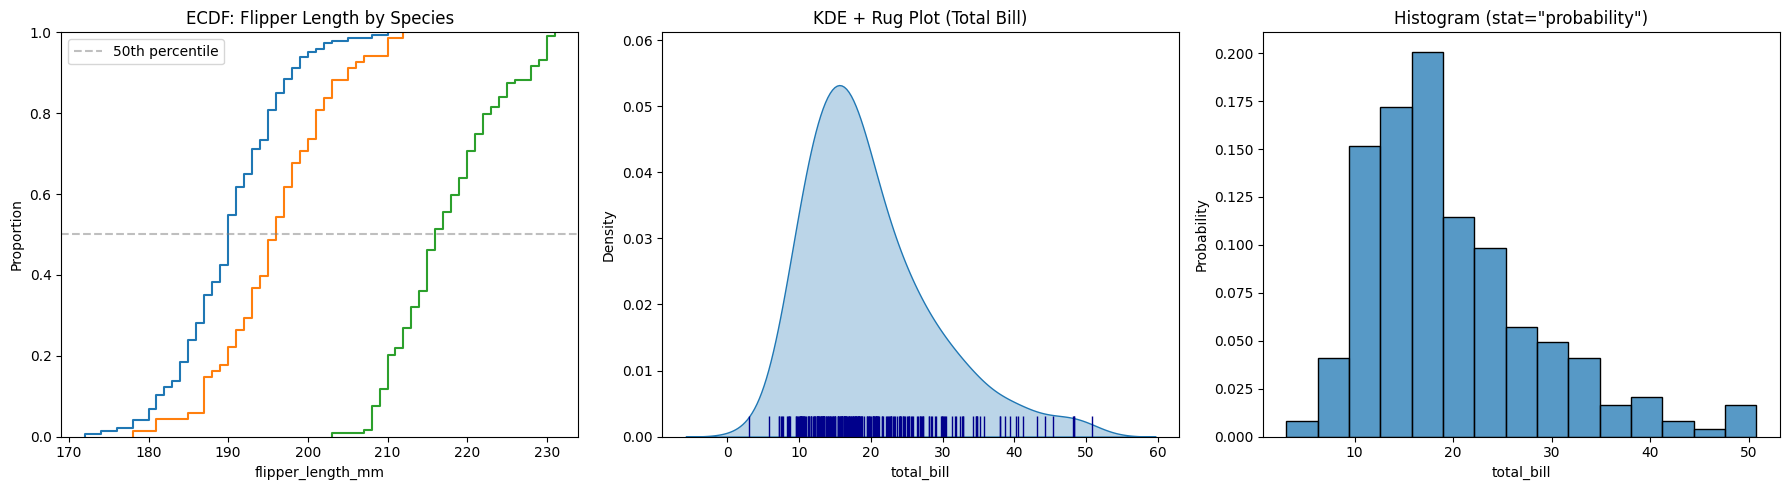

In [5]:
# --- ECDF and Rug plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ECDF — cumulative distribution
sns.ecdfplot(data=penguins, x='flipper_length_mm', hue='species', ax=axes[0])
axes[0].set_title('ECDF: Flipper Length by Species')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='50th percentile')
axes[0].legend()

# Rug plot overlaid on KDE
sns.kdeplot(data=tips, x='total_bill', fill=True, alpha=0.3, ax=axes[1])
sns.rugplot(data=tips, x='total_bill', height=0.05, color='darkblue', ax=axes[1])
axes[1].set_title('KDE + Rug Plot (Total Bill)')

# Histogram with multiple stat options
sns.histplot(data=tips, x='total_bill', stat='probability', bins=15,
             edgecolor='black', ax=axes[2])
axes[2].set_title('Histogram (stat="probability")')

plt.tight_layout()
plt.show()

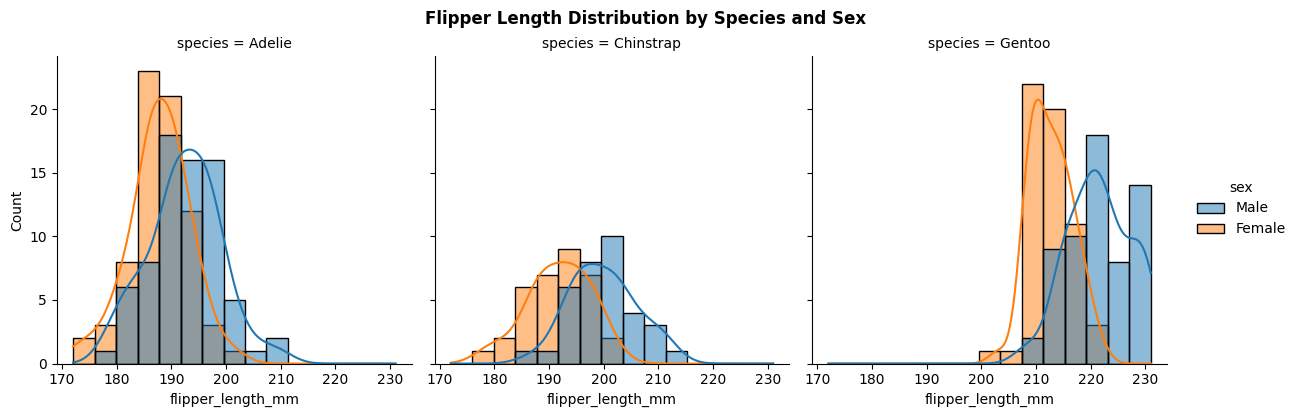

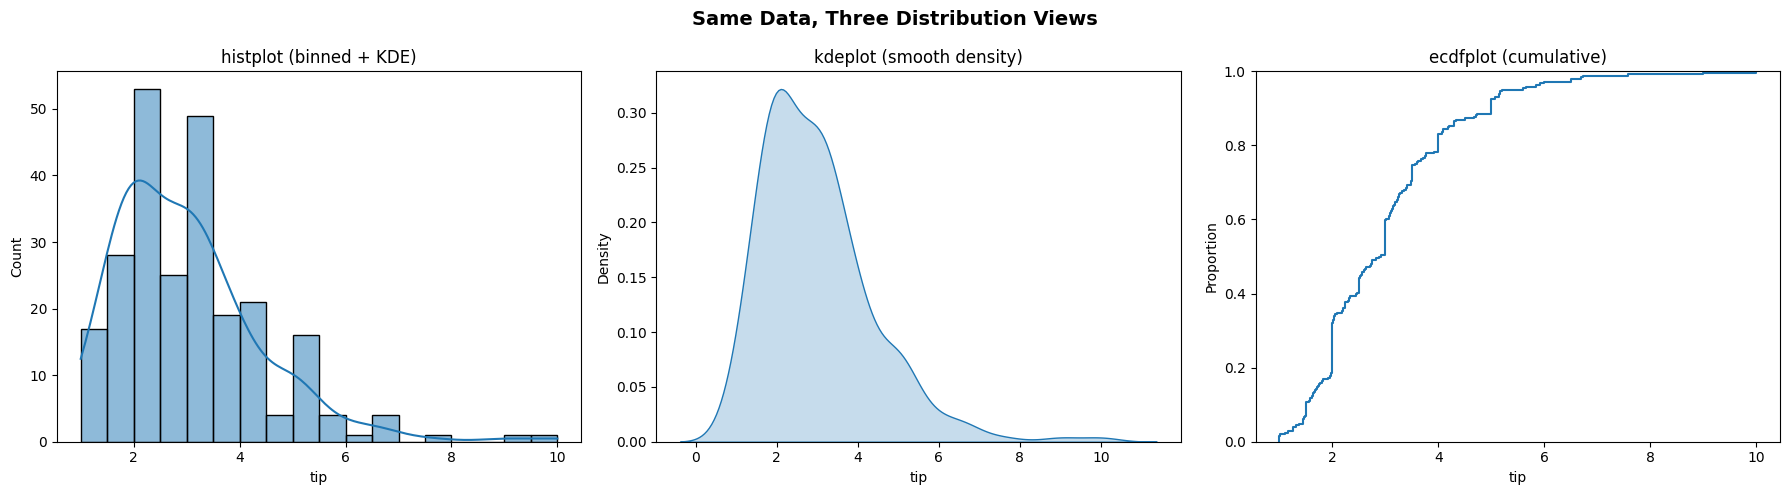

In [6]:
# --- displot: figure-level distribution plots with faceting ---

# Faceted histograms by species
g = sns.displot(data=penguins, x='flipper_length_mm', hue='sex',
                col='species', kind='hist', kde=True,
                height=4, aspect=1.0, bins=15)
g.fig.suptitle('Flipper Length Distribution by Species and Sex', y=1.03, fontweight='bold')
plt.show()

# Compare distribution types side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Same Data, Three Distribution Views', fontsize=14, fontweight='bold')

sns.histplot(data=tips, x='tip', kde=True, ax=axes[0])
axes[0].set_title('histplot (binned + KDE)')

sns.kdeplot(data=tips, x='tip', fill=True, ax=axes[1])
axes[1].set_title('kdeplot (smooth density)')

sns.ecdfplot(data=tips, x='tip', ax=axes[2])
axes[2].set_title('ecdfplot (cumulative)')

plt.tight_layout()
plt.show()

---
## 3. Categorical Plots — Comparing Groups

Categorical plots answer: *"How does a numeric variable differ across categories?"*

### Categorical Plot Types

| Function | Shows | Best For | Data Points Visible? |
|----------|-------|----------|---------------------|
| `stripplot()` | Individual points (jittered) | Small datasets, exact values | Yes |
| `swarmplot()` | Non-overlapping points | Small-medium datasets | Yes |
| `boxplot()` | Quartiles + outliers | Quick summary statistics | Outliers only |
| `violinplot()` | KDE + box | Distribution shape comparison | No |
| `barplot()` | Mean + confidence interval | Simple group comparison | No |
| `countplot()` | Frequency counts | Categorical frequency | No |
| `pointplot()` | Mean + CI as connected points | Interaction effects | No |

### Combining Categorical Plots

A powerful technique is **layering** — e.g., a violin or box plot with individual points overlaid:

```python
sns.violinplot(data=tips, x='day', y='total_bill', inner=None, alpha=0.3)
sns.stripplot(data=tips, x='day', y='total_bill', size=3, alpha=0.6)
```

### catplot() — Figure-Level Wrapper

| Parameter | Purpose | Example |
|-----------|---------|---------|
| `kind` | Plot type | `'strip'`, `'swarm'`, `'box'`, `'violin'`, `'bar'`, `'count'`, `'point'` |
| `col` | Facet by column | `col='smoker'` |
| `row` | Facet by row | `row='time'` |
| `order` | Category order | `order=['Thur', 'Fri', 'Sat', 'Sun']` |

> ⚠️ **Special Case — `swarmplot()` with large data**: Swarm plots don't scale well beyond ~300 points per category. Use `stripplot()` with `alpha=0.3` for larger datasets.

> ⚠️ **Special Case — `violinplot()` `inner` parameter**: Set `inner='quartile'` to show quartile lines, `inner='stick'` for data sticks, or `inner=None` when layering with strip/swarm.

> **Data Science relevance**: Categorical plots are essential for A/B testing analysis, cohort comparison, and understanding feature distributions across groups.

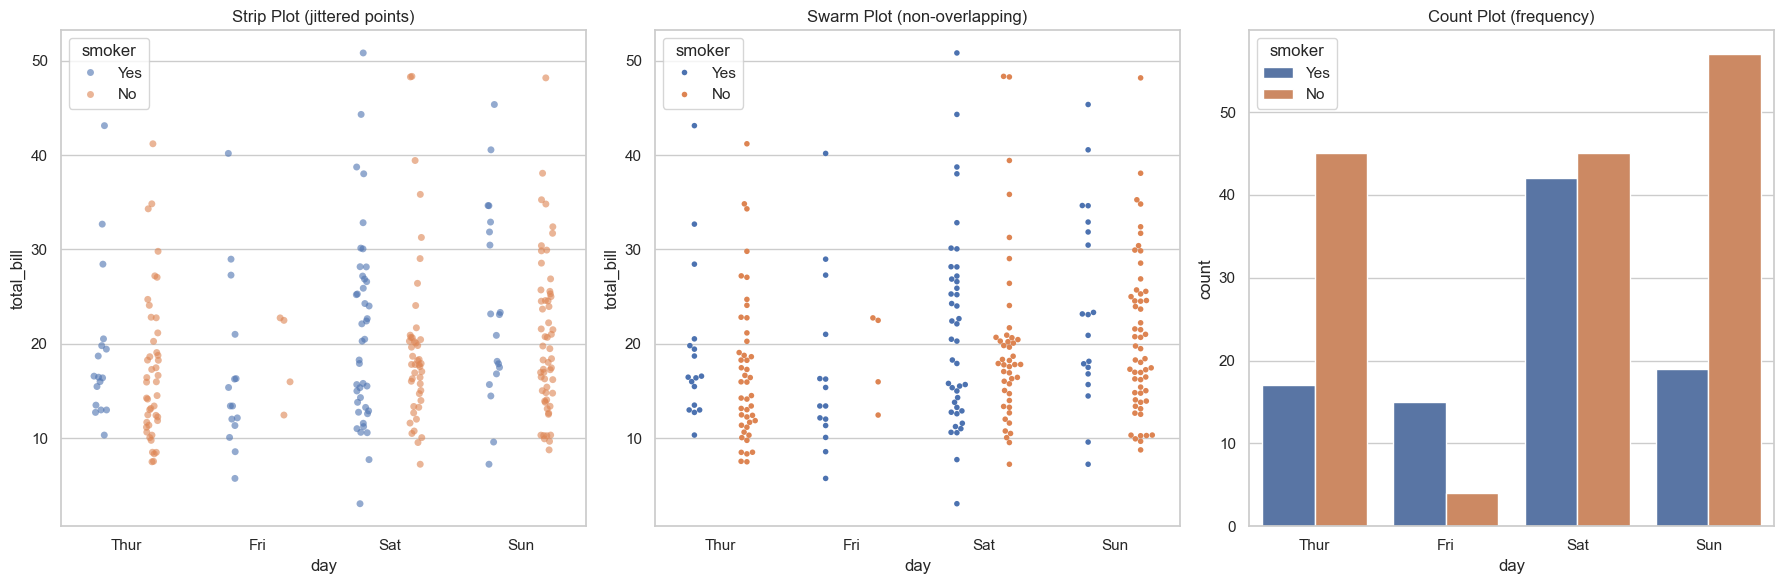

In [20]:
# --- Strip, Swarm, and Count plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Strip plot — jittered individual points
sns.stripplot(data=tips, x='day', y='total_bill', hue='smoker',
              dodge=True, alpha=0.6, ax=axes[0])
axes[0].set_title('Strip Plot (jittered points)')

# Swarm plot — non-overlapping points
sns.swarmplot(data=tips, x='day', y='total_bill', hue='smoker',
              dodge=True, size=4, ax=axes[1])
axes[1].set_title('Swarm Plot (non-overlapping)')

# Count plot — frequency of categories
sns.countplot(data=tips, x='day', hue='smoker',
              order=['Thur', 'Fri', 'Sat', 'Sun'], ax=axes[2])
axes[2].set_title('Count Plot (frequency)')

plt.tight_layout()
plt.show()

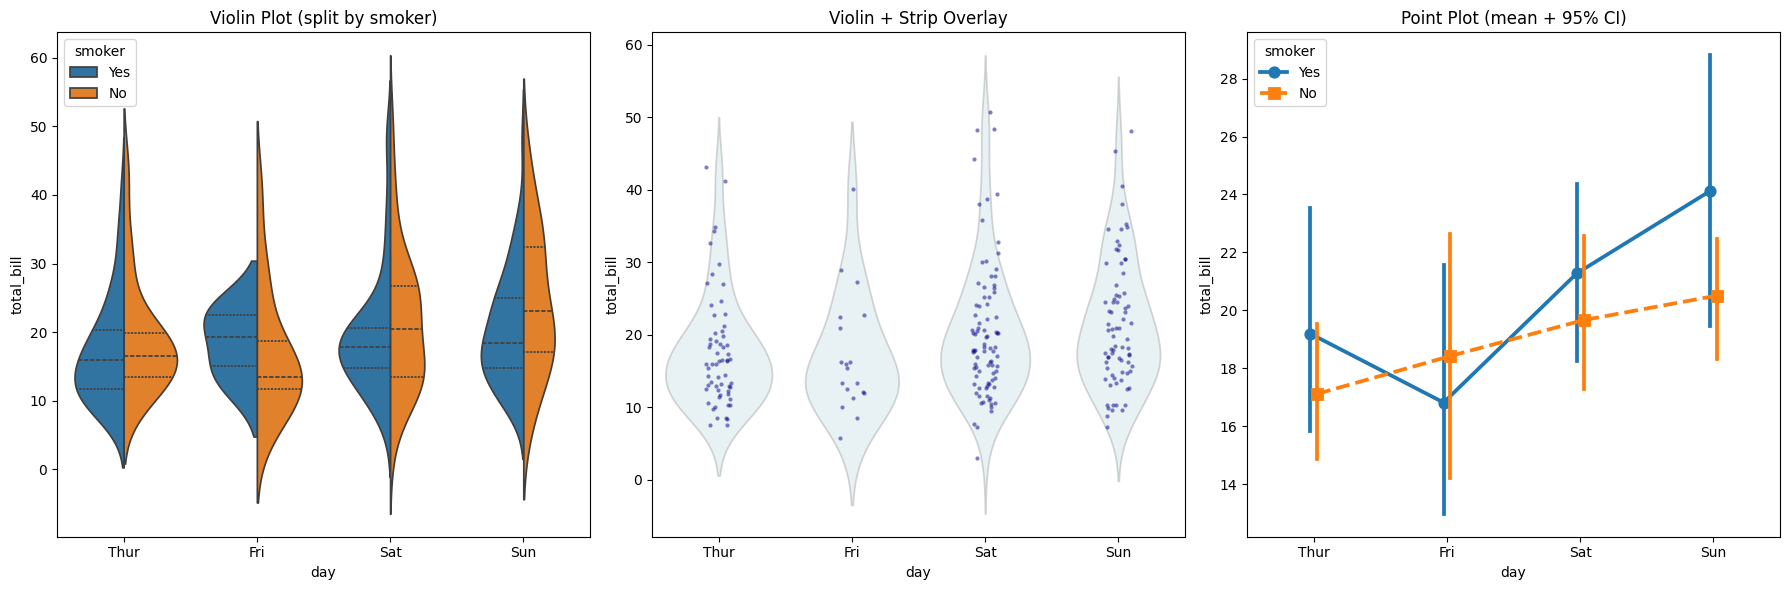

In [8]:
# --- Violin and Point plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Violin plot — shows full distribution shape
sns.violinplot(data=tips, x='day', y='total_bill', hue='smoker',
               split=True, inner='quartile', ax=axes[0])
axes[0].set_title('Violin Plot (split by smoker)')

# Layered: violin + strip for best of both worlds
sns.violinplot(data=tips, x='day', y='total_bill', inner=None,
               color='lightblue', alpha=0.3, ax=axes[1])
sns.stripplot(data=tips, x='day', y='total_bill',
              size=3, color='darkblue', alpha=0.5, ax=axes[1])
axes[1].set_title('Violin + Strip Overlay')

# Point plot — means with CI, great for interactions
sns.pointplot(data=tips, x='day', y='total_bill', hue='smoker',
              dodge=True, markers=['o', 's'], linestyles=['-', '--'],
              errorbar='ci', ax=axes[2])
axes[2].set_title('Point Plot (mean + 95% CI)')

plt.tight_layout()
plt.show()

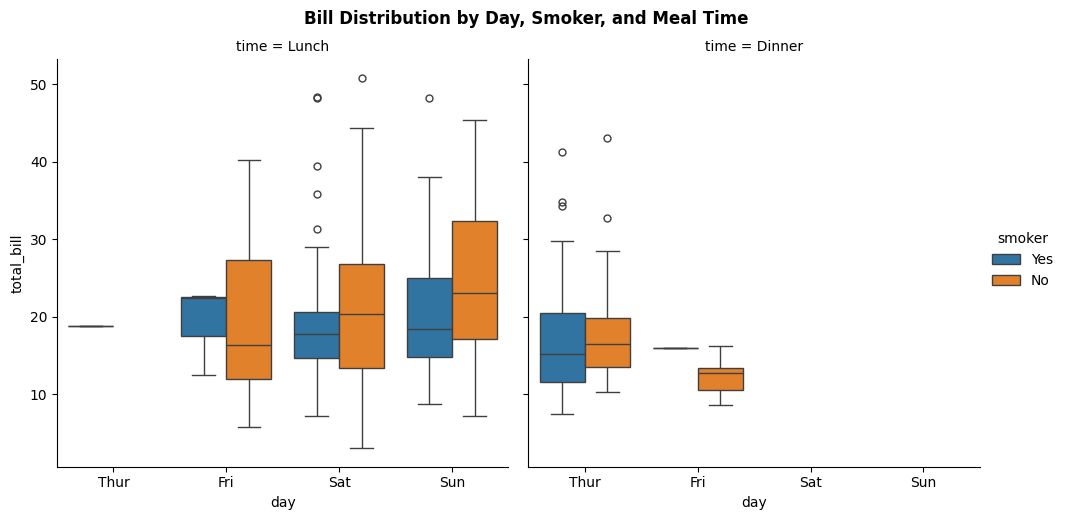

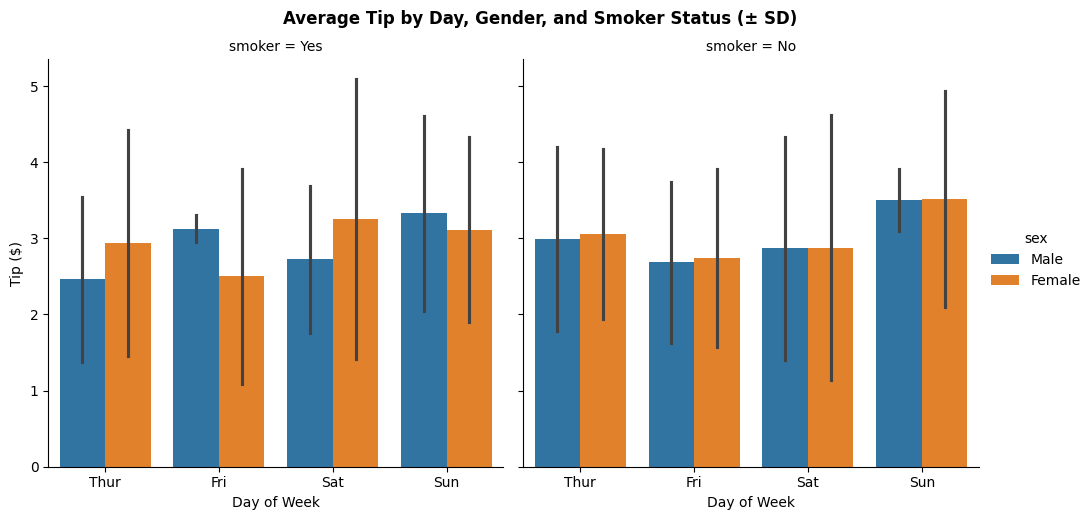

In [9]:
# --- catplot: figure-level categorical with faceting ---

# Faceted box plots
g = sns.catplot(data=tips, x='day', y='total_bill', hue='smoker',
                col='time', kind='box',
                order=['Thur', 'Fri', 'Sat', 'Sun'],
                height=5, aspect=1.0)
g.fig.suptitle('Bill Distribution by Day, Smoker, and Meal Time', y=1.03, fontweight='bold')
plt.show()

# Faceted bar plots with custom order
g = sns.catplot(data=tips, x='day', y='tip', hue='sex',
                col='smoker', kind='bar',
                order=['Thur', 'Fri', 'Sat', 'Sun'],
                height=5, aspect=1.0, errorbar='sd')
g.fig.suptitle('Average Tip by Day, Gender, and Smoker Status (± SD)', y=1.03, fontweight='bold')
g.set_axis_labels('Day of Week', 'Tip ($)')
plt.show()

---
## 4. Regression & Relationship Plots

Seaborn makes it trivial to visualize relationships between variables and fit regression models visually.

### Regression Functions

| Function | Level | What It Does |
|----------|-------|-------------|
| `regplot()` | Axes-level | Scatter + regression line on existing axes |
| `lmplot()` | Figure-level | Scatter + regression with faceting support |
| `residplot()` | Axes-level | Residuals of a regression fit (diagnostic) |
| `jointplot()` | Figure-level | Bivariate plot with marginal distributions |

### Key Parameters

| Parameter | Purpose | Options |
|-----------|---------|---------|
| `order` | Polynomial degree | `order=2` for quadratic fit |
| `logistic` | Logistic regression | `logistic=True` for binary outcomes |
| `lowess` | Non-parametric fit | `lowess=True` for flexible curves |
| `robust` | Robust regression | `robust=True` to downweight outliers |
| `ci` | Confidence interval width | `ci=95` (default), `ci=None` to hide |

### jointplot Kinds

| Kind | Description | Use Case |
|------|-------------|----------|
| `'scatter'` | Scatter + marginal histograms | Default bivariate view |
| `'kde'` | 2D KDE contours + marginal KDE | Density estimation |
| `'hex'` | Hexbin + marginal histograms | Large datasets (overplotting) |
| `'reg'` | Scatter + regression + marginals | Relationship + distribution |
| `'hist'` | 2D histogram + marginal histograms | Binned density |

> ⚠️ **Special Case — `regplot` vs `lmplot`**: Use `regplot()` when you need to place the plot on an existing axes. Use `lmplot()` when you want automatic faceting via `col`/`row`/`hue`.

> **Data Science relevance**: Visual regression diagnostics catch non-linearity, heteroscedasticity, and influential outliers that summary statistics miss.

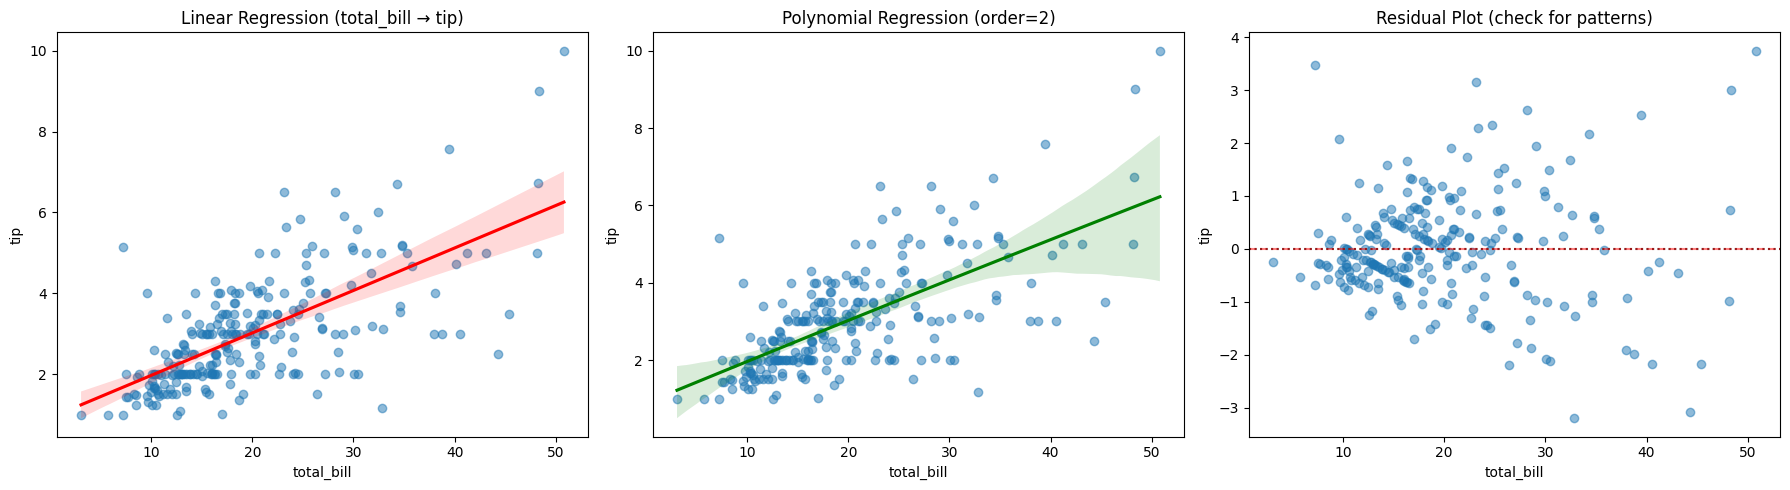

In [10]:
# --- regplot and residplot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Linear regression
sns.regplot(data=tips, x='total_bill', y='tip', ci=95,
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'}, ax=axes[0])
axes[0].set_title('Linear Regression (total_bill → tip)')

# Polynomial regression (order=2)
sns.regplot(data=tips, x='total_bill', y='tip', order=2, ci=95,
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'green'}, ax=axes[1])
axes[1].set_title('Polynomial Regression (order=2)')

# Residual plot — are residuals random?
sns.residplot(data=tips, x='total_bill', y='tip',
              scatter_kws={'alpha': 0.5}, ax=axes[2])
axes[2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('Residual Plot (check for patterns)')

plt.tight_layout()
plt.show()

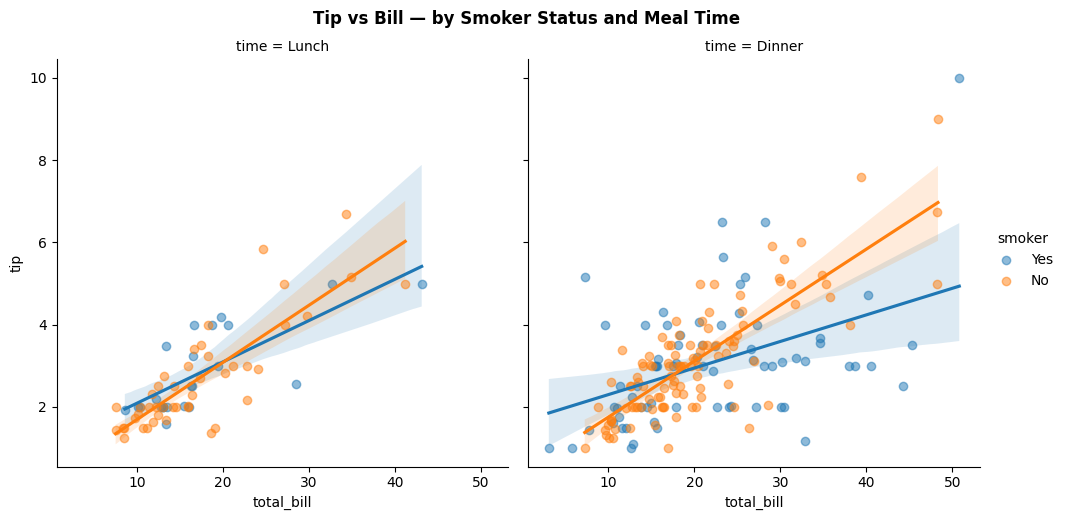

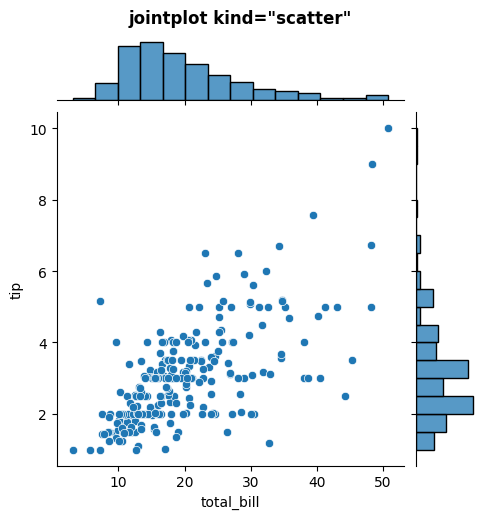

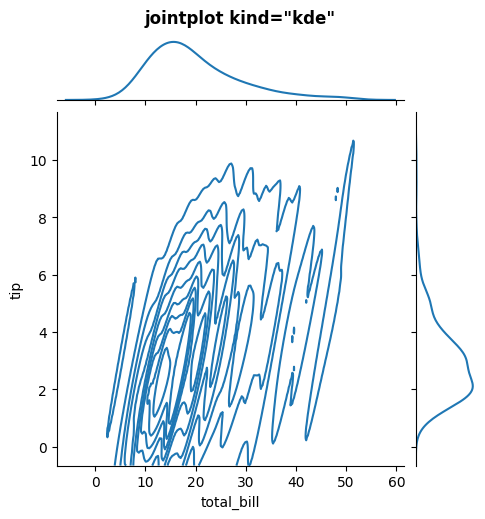

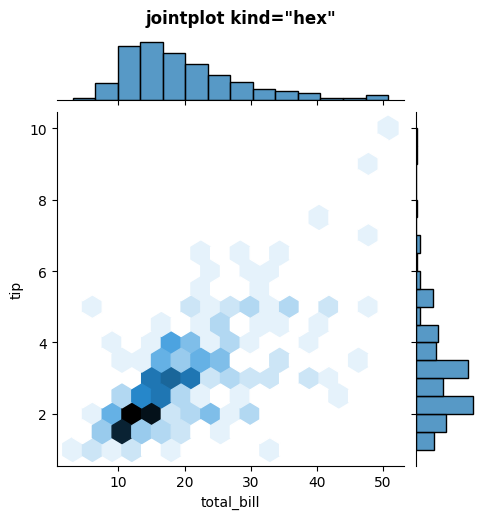

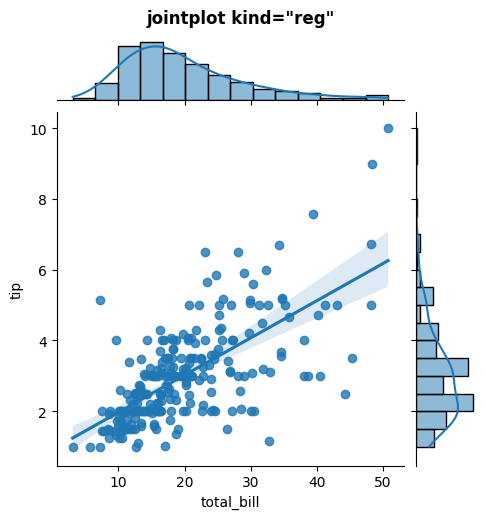

In [11]:
# --- lmplot with faceting ---

# Regression lines by category
g = sns.lmplot(data=tips, x='total_bill', y='tip', hue='smoker',
               col='time', height=5, aspect=1.0,
               scatter_kws={'alpha': 0.5})
g.fig.suptitle('Tip vs Bill — by Smoker Status and Meal Time', y=1.03, fontweight='bold')
plt.show()

# --- jointplot varieties ---
fig_titles = ['scatter (default)', 'kde (density)', 'hex (large data)', 'reg (regression)']
kinds = ['scatter', 'kde', 'hex', 'reg']

for kind, title in zip(kinds, fig_titles):
    g = sns.jointplot(data=tips, x='total_bill', y='tip', kind=kind, height=5)
    g.fig.suptitle(f'jointplot kind="{kind}"', y=1.03, fontweight='bold')
    plt.show()

---
## 5. Multi-Panel Grids — FacetGrid and PairGrid

Grids let you create matrices of plots split by one or more categorical variables. This is one of Seaborn's most powerful features.

### Grid Types

| Grid | Purpose | Created By |
|------|---------|-----------|
| `FacetGrid` | Map a plot function across subsets of data | `sns.FacetGrid()` + `.map()` |
| `PairGrid` | Map plot functions to pairs of variables | `sns.PairGrid()` + `.map_*()` |
| `JointGrid` | Bivariate + marginal plots | `sns.JointGrid()` + `.plot()` |

### FacetGrid Parameters

| Parameter | Purpose | Example |
|-----------|---------|---------|
| `col` | Split into columns | `col='species'` |
| `row` | Split into rows | `row='sex'` |
| `hue` | Color by category | `hue='island'` |
| `col_wrap` | Max columns before wrapping | `col_wrap=3` |
| `height` / `aspect` | Size control | `height=4, aspect=1.2` |
| `sharex` / `sharey` | Share axis scales | `sharex=True` |

### PairGrid Mapping Methods

| Method | Applies To | Use Case |
|--------|-----------|----------|
| `.map()` | All panels | Same plot everywhere |
| `.map_diag()` | Diagonal only | Histograms, KDE |
| `.map_upper()` | Upper triangle | Scatter, regression |
| `.map_lower()` | Lower triangle | KDE, hex |
| `.map_offdiag()` | Off-diagonal | Same plot for all pairs |

> ⚠️ **Special Case — `FacetGrid.map()` syntax**: Pass the plotting function (not a call), then column names as strings: `g.map(sns.histplot, 'total_bill')`.

> **Data Science relevance**: FacetGrid is the backbone of multi-dimensional EDA. It replaces dozens of manual plots with a single, systematic view of how variables interact across groups.

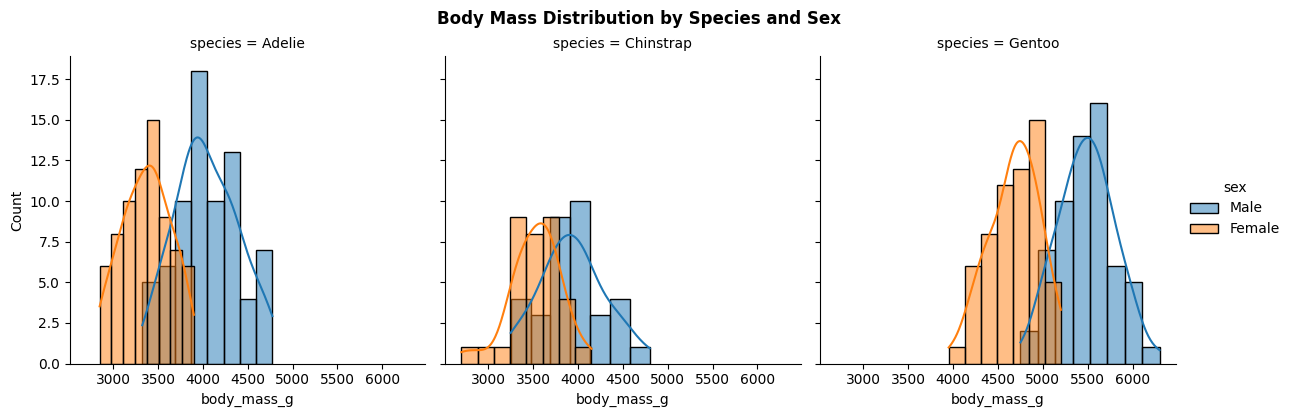

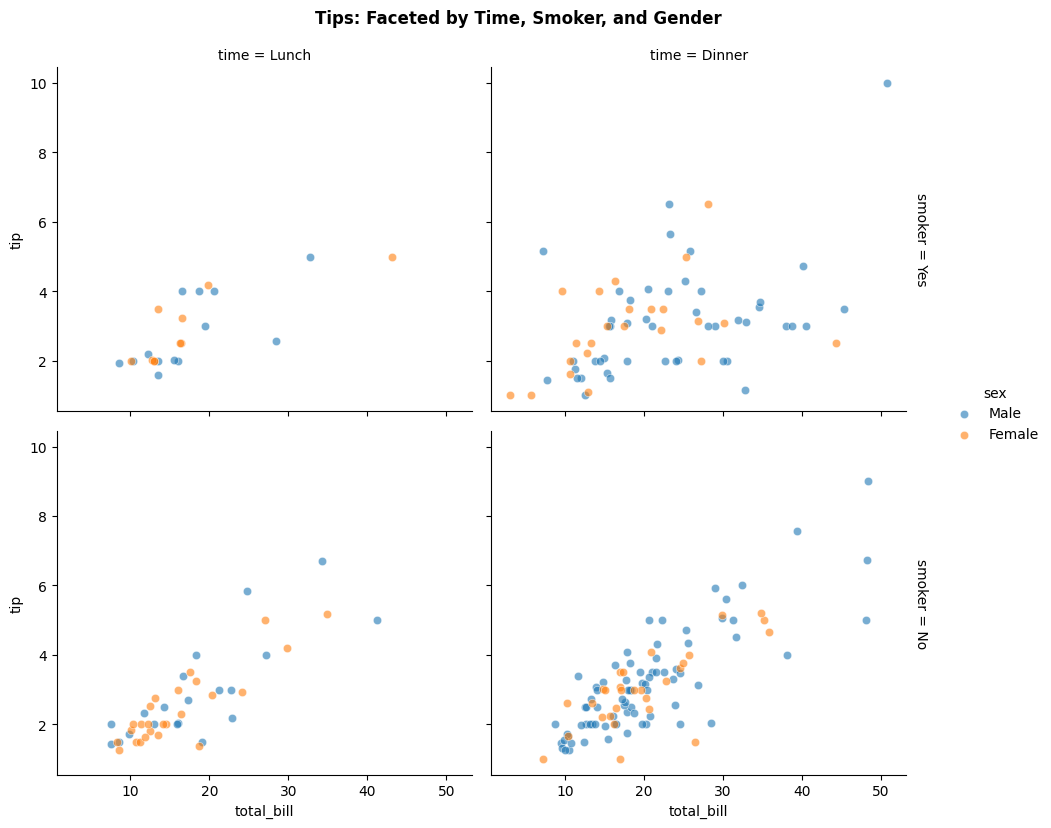

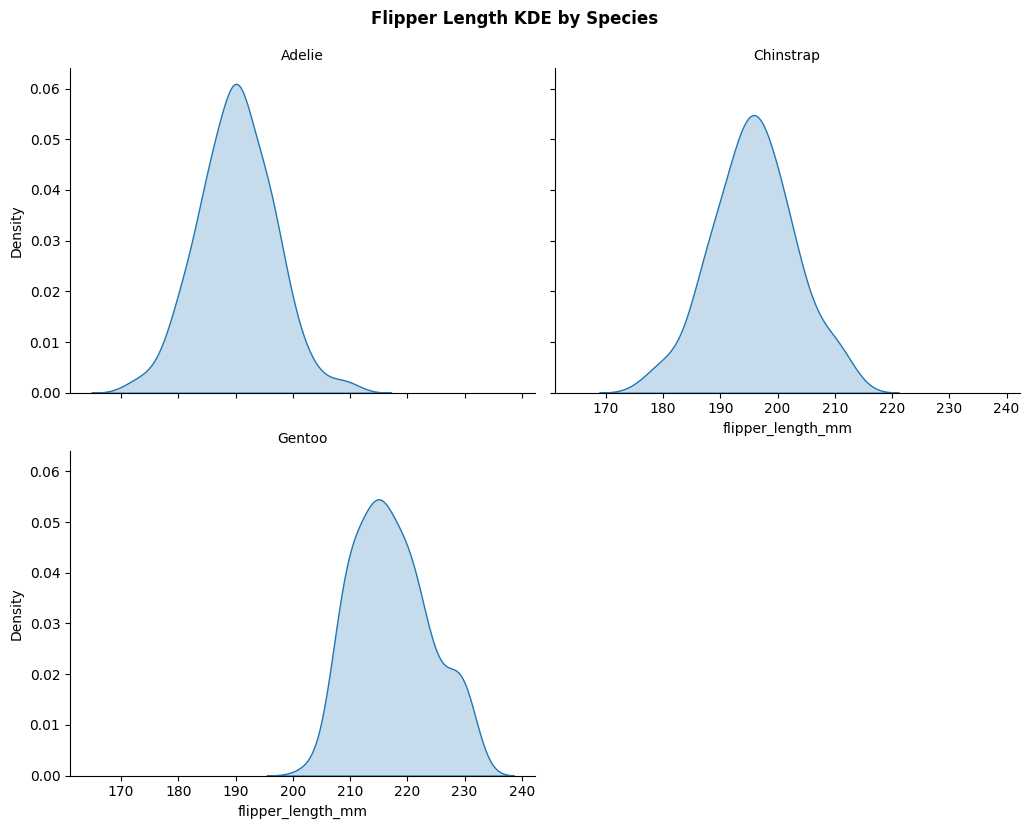

In [12]:
# --- FacetGrid ---

# Basic FacetGrid with histograms
g = sns.FacetGrid(penguins, col='species', hue='sex', height=4, aspect=1.0)
g.map(sns.histplot, 'body_mass_g', kde=True, alpha=0.5)
g.add_legend()
g.fig.suptitle('Body Mass Distribution by Species and Sex', y=1.03, fontweight='bold')
plt.show()

# FacetGrid with row and column
g = sns.FacetGrid(tips, col='time', row='smoker', hue='sex',
                  height=4, aspect=1.2, margin_titles=True)
g.map(sns.scatterplot, 'total_bill', 'tip', alpha=0.6)
g.add_legend()
g.fig.suptitle('Tips: Faceted by Time, Smoker, and Gender', y=1.03, fontweight='bold')
plt.show()

# FacetGrid with col_wrap for many categories
g = sns.FacetGrid(penguins, col='species', col_wrap=2, height=4, aspect=1.3)
g.map(sns.kdeplot, 'flipper_length_mm', fill=True)
g.set_titles('{col_name}')
g.fig.suptitle('Flipper Length KDE by Species', y=1.03, fontweight='bold')
plt.show()

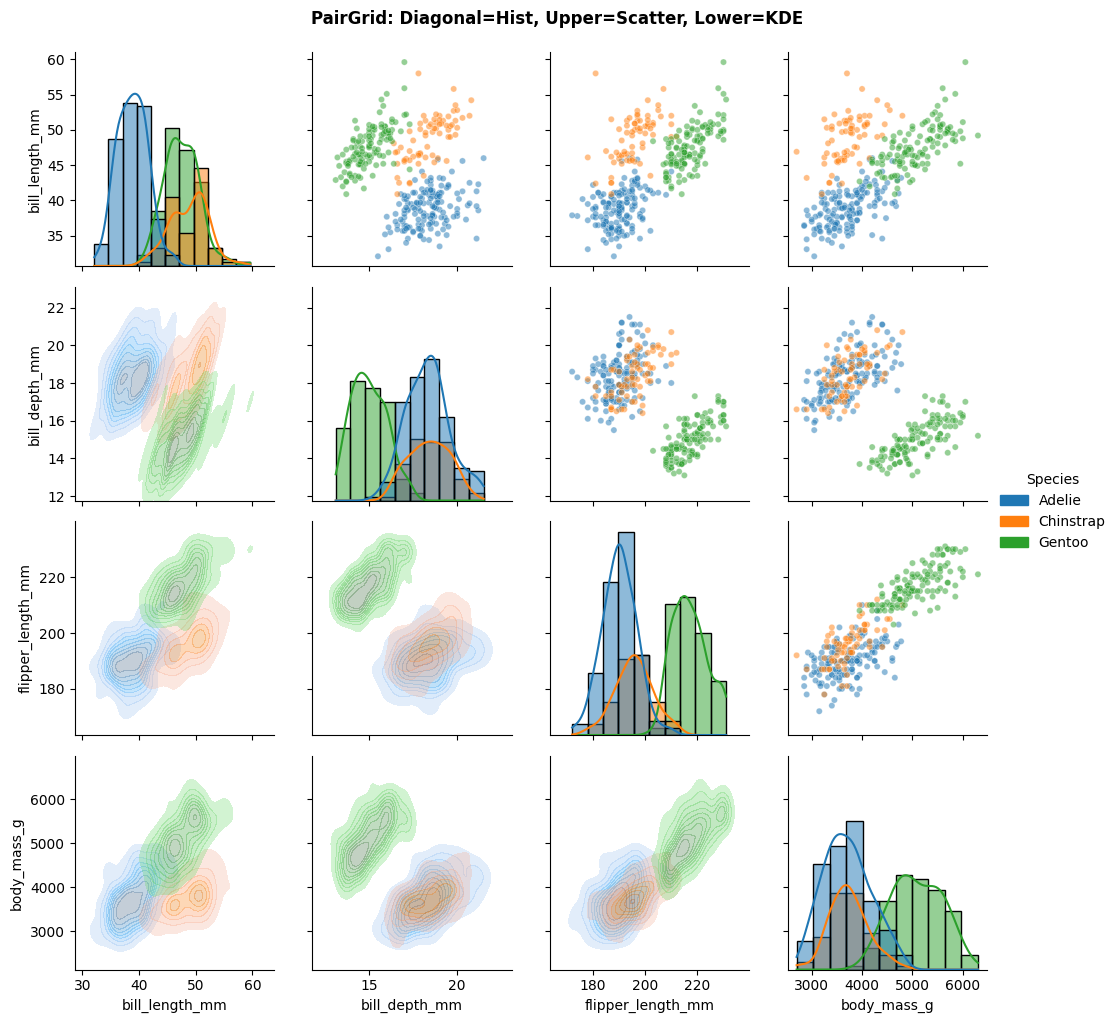

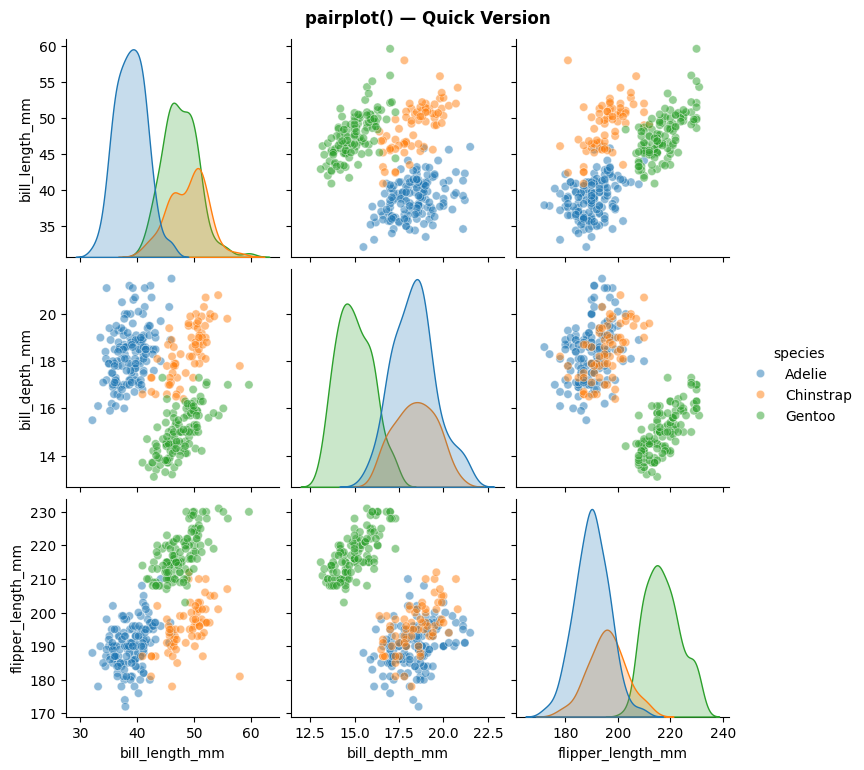

In [13]:
# --- PairGrid — asymmetric pair plots ---

# Custom PairGrid with different plots in each region
g = sns.PairGrid(penguins, hue='species',
                 vars=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'])

g.map_diag(sns.histplot, kde=True, alpha=0.5)
g.map_upper(sns.scatterplot, alpha=0.5, s=20)
g.map_lower(sns.kdeplot, fill=True, alpha=0.3)

g.add_legend(title='Species')
g.fig.suptitle('PairGrid: Diagonal=Hist, Upper=Scatter, Lower=KDE', y=1.02, fontweight='bold')
plt.show()

# Compare with simple pairplot (same result, less control)
g = sns.pairplot(penguins, hue='species',
                 vars=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm'],
                 diag_kind='kde', plot_kws={'alpha': 0.5})
g.fig.suptitle('pairplot() — Quick Version', y=1.02, fontweight='bold')
plt.show()

---
## 6. Styling, Palettes & Publication-Ready Figures

Seaborn provides a complete theming system to control the look and feel of your plots.

### Style Functions

| Function | Controls | Options |
|----------|---------|---------|
| `set_style()` | Background, grid, spines | `'darkgrid'`, `'whitegrid'`, `'dark'`, `'white'`, `'ticks'` |
| `set_context()` | Element scaling | `'paper'`, `'notebook'`, `'talk'`, `'poster'` |
| `set_palette()` | Default color cycle | Named palettes or custom lists |
| `despine()` | Remove spines | `top=True`, `right=True`, `left=False`, `bottom=False` |
| `set_theme()` | All-in-one | Combines style, context, palette, font |

### Color Palettes

| Palette Type | Use Case | Examples |
|-------------|----------|---------|
| **Qualitative** | Distinct categories | `'Set2'`, `'husl'`, `'tab10'`, `'pastel'` |
| **Sequential** | Ordered magnitude | `'Blues'`, `'viridis'`, `'rocket'`, `'mako'` |
| **Diverging** | Centered at midpoint | `'coolwarm'`, `'vlag'`, `'icefire'` |

### Colorblind-Safe Palettes

| Palette | Type | Safe? |
|---------|------|-------|
| `'colorblind'` | Qualitative | Yes |
| `'viridis'` | Sequential | Yes |
| `'cividis'` | Sequential | Yes |
| `'tab10'` | Qualitative | Mostly |

### Context Scaling

| Context | Font Scale | Line Width | Best For |
|---------|-----------|-----------|----------|
| `'paper'` | 0.8 | thin | Journal articles |
| `'notebook'` | 1.0 | medium | Jupyter notebooks (default) |
| `'talk'` | 1.3 | thick | Presentations |
| `'poster'` | 1.6 | very thick | Conference posters |

> ⚠️ **Special Case — Global state**: `set_style()`, `set_context()`, and `set_palette()` change **global** defaults. Use `with sns.axes_style()` or `with sns.plotting_context()` for temporary changes.

> ⚠️ **Special Case — Accessibility**: ~8% of males have color vision deficiency. Always use colorblind-safe palettes for public-facing work. Add redundant encoding (shapes, labels) when possible.

> **Data Science relevance**: Consistent, accessible styling is the difference between a notebook sketch and a presentation-ready figure. `set_context('talk')` alone can save 30 minutes of manual formatting.

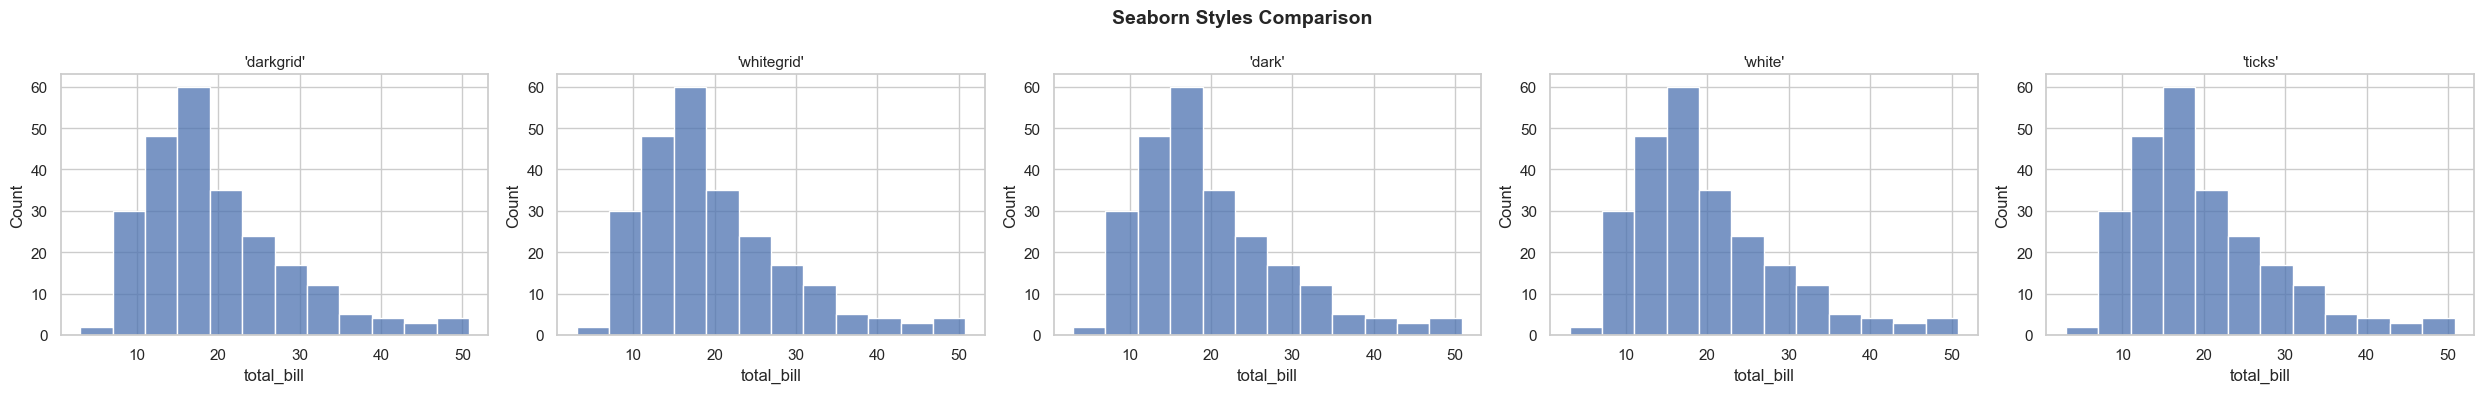

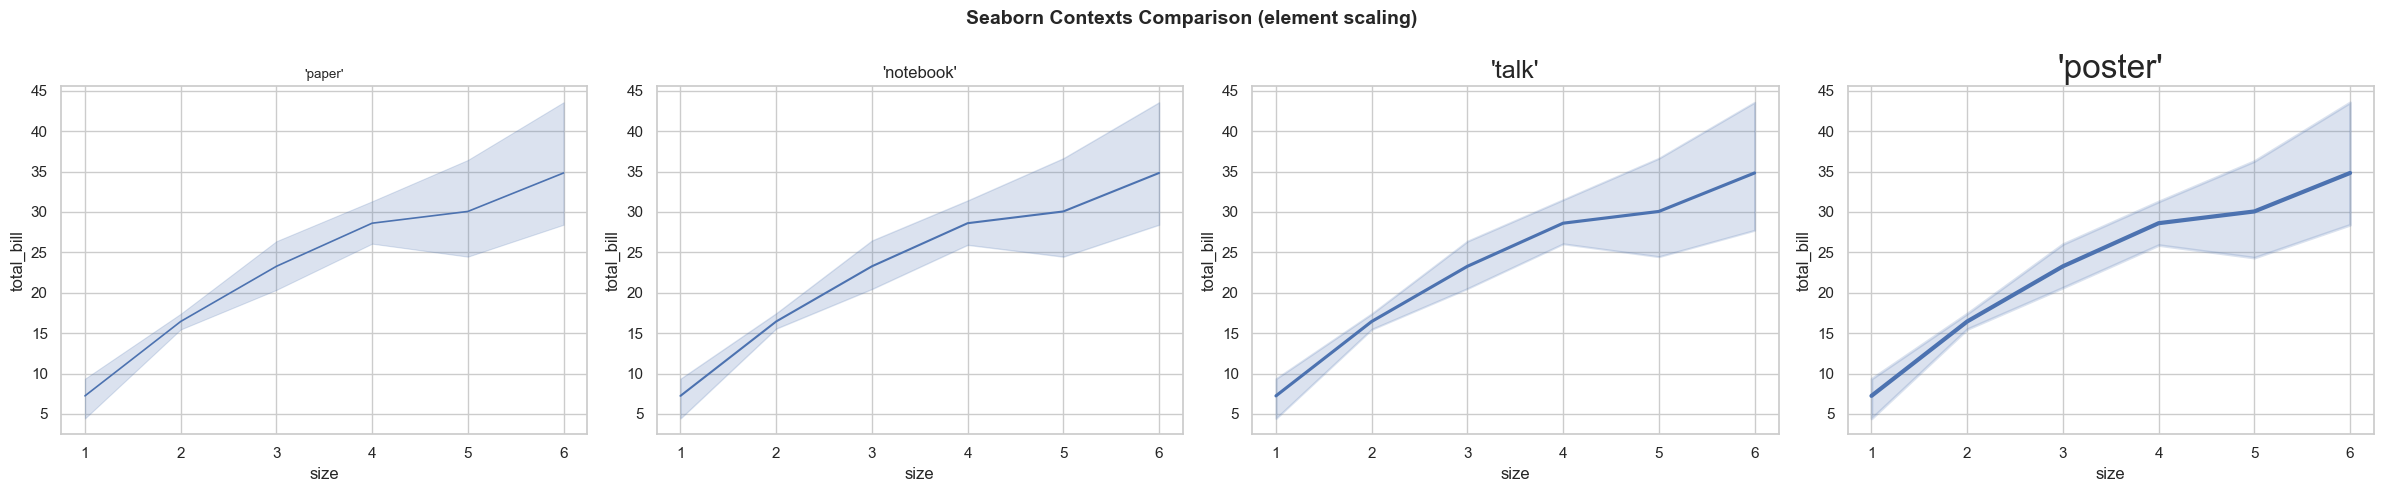

In [21]:
# --- Styles and contexts comparison ---

# Compare all 5 styles
styles = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']
fig, axes = plt.subplots(1, 5, figsize=(25, 4))

for ax, style in zip(axes, styles):
    with sns.axes_style(style):
        sns.histplot(data=tips, x='total_bill', bins=12, ax=ax)
        ax.set_title(f"'{style}'", fontsize=11)

fig.suptitle('Seaborn Styles Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Compare all 4 contexts
contexts = ['paper', 'notebook', 'talk', 'poster']
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, ctx in zip(axes, contexts):
    with sns.plotting_context(ctx):
        sns.lineplot(data=tips, x='size', y='total_bill', ax=ax)
        ax.set_title(f"'{ctx}'")

fig.suptitle('Seaborn Contexts Comparison (element scaling)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

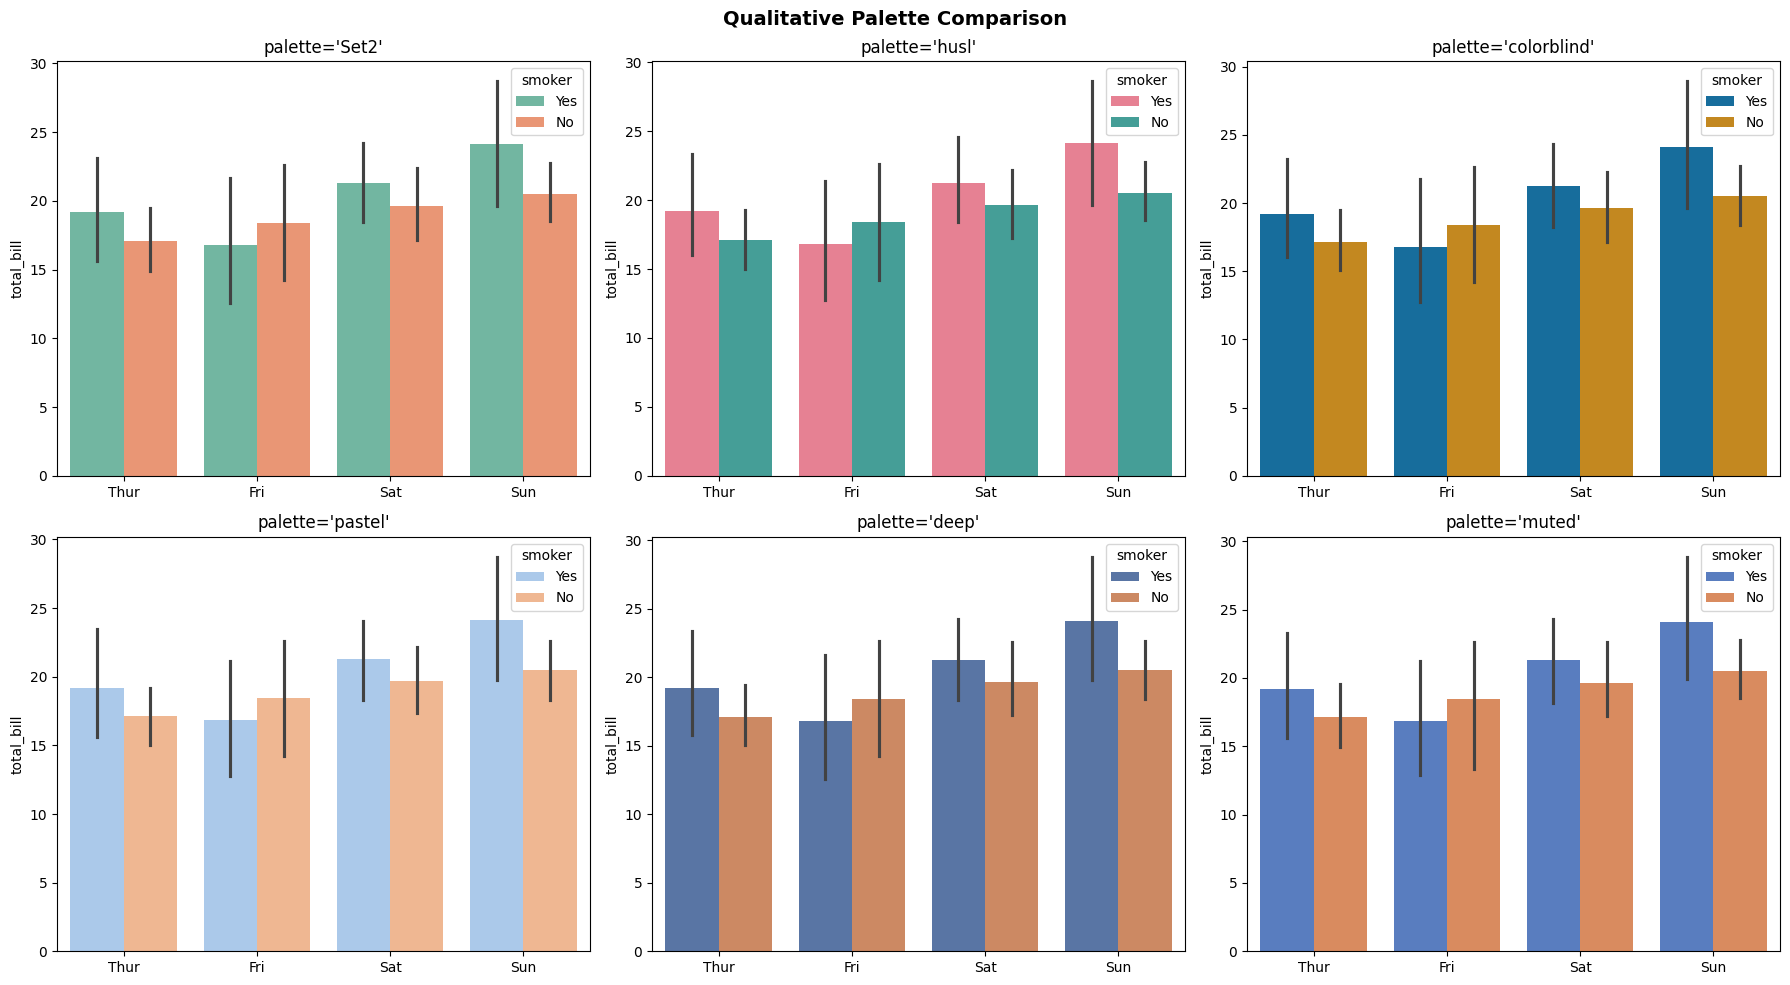

Palette swatches:

  Set2:


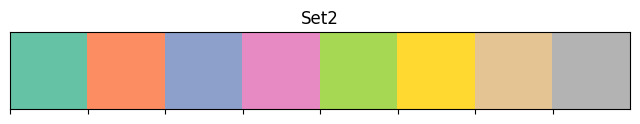


  viridis:


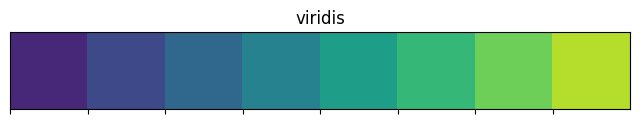


  coolwarm:


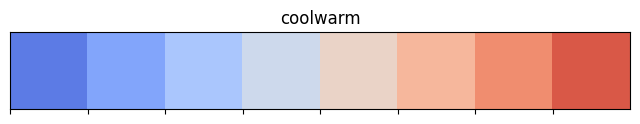


  colorblind:


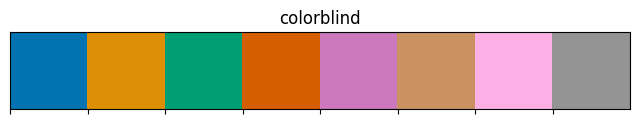

In [15]:
# --- Color palettes ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Qualitative palettes
palettes = ['Set2', 'husl', 'colorblind', 'pastel', 'deep', 'muted']
for ax, pal_name in zip(axes.flat, palettes):
    sns.barplot(data=tips, x='day', y='total_bill', hue='smoker',
                palette=pal_name, ax=ax, order=['Thur', 'Fri', 'Sat', 'Sun'])
    ax.set_title(f"palette='{pal_name}'")
    ax.set_xlabel('')

fig.suptitle('Qualitative Palette Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Display palette swatches
print("Palette swatches:")
for name in ['Set2', 'viridis', 'coolwarm', 'colorblind']:
    print(f"\n  {name}:")
    sns.palplot(sns.color_palette(name, 8))
    plt.title(name)
    plt.show()

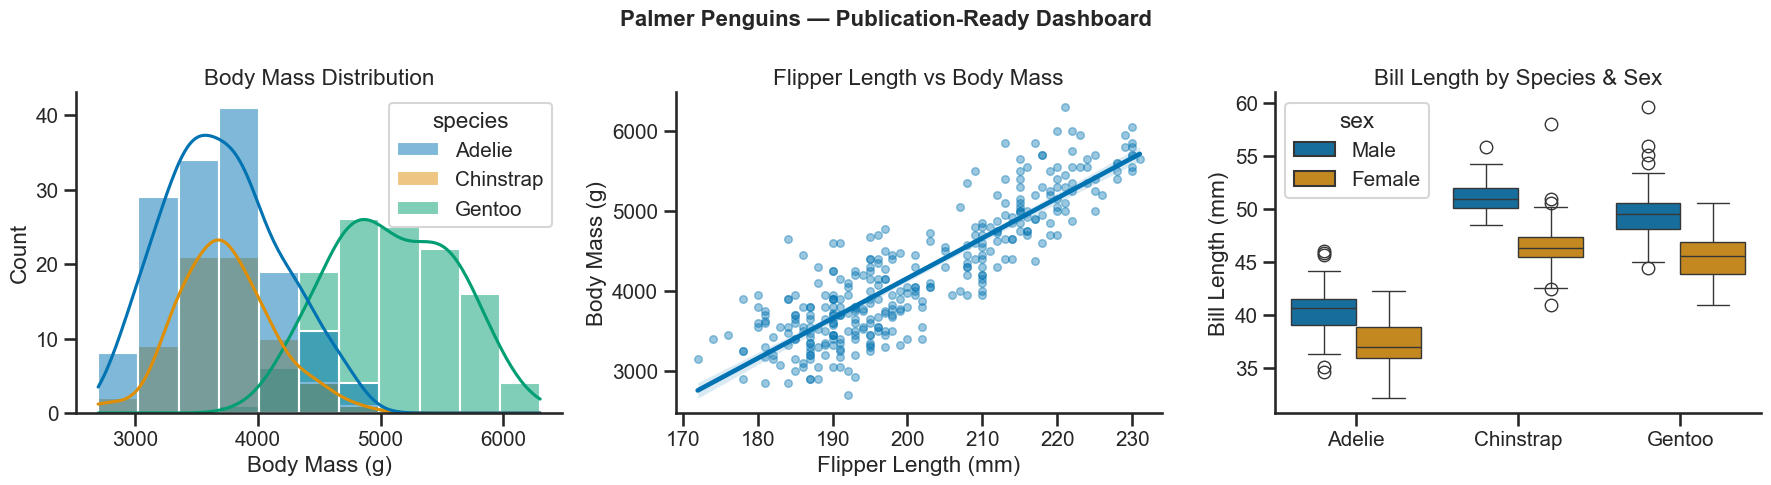

Saved: penguin_analysis.png (300 DPI)


In [16]:
# --- Publication-ready figure example ---

# Set professional theme
sns.set_theme(style='ticks', context='talk', palette='colorblind',
              font_scale=0.9)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Distribution
sns.histplot(data=penguins, x='body_mass_g', hue='species',
             kde=True, alpha=0.5, ax=axes[0])
axes[0].set_title('Body Mass Distribution')
axes[0].set_xlabel('Body Mass (g)')

# Plot 2: Relationship
sns.regplot(data=penguins, x='flipper_length_mm', y='body_mass_g',
            scatter_kws={'alpha': 0.4, 's': 30}, ax=axes[1])
axes[1].set_title('Flipper Length vs Body Mass')
axes[1].set_xlabel('Flipper Length (mm)')
axes[1].set_ylabel('Body Mass (g)')

# Plot 3: Categorical
sns.boxplot(data=penguins, x='species', y='bill_length_mm',
            hue='sex', ax=axes[2])
axes[2].set_title('Bill Length by Species & Sex')
axes[2].set_xlabel('')
axes[2].set_ylabel('Bill Length (mm)')

sns.despine()
fig.suptitle('Palmer Penguins — Publication-Ready Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()

fig.savefig('penguin_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: penguin_analysis.png (300 DPI)")

# Reset to notebook defaults
sns.set_theme(style='whitegrid', context='notebook')

---
## 🧪 Practice Exercises

**Distribution Plots**
1. Load the `iris` dataset. Create KDE plots of `petal_length` for each species, overlaid on the same axes with `fill=True` and `alpha=0.4`.
2. Using the `tips` dataset, create a figure with 3 subplots showing `total_bill` as: (a) histogram with KDE, (b) ECDF, (c) KDE + rug plot.
3. Use `displot()` to create faceted histograms of `tip` amount, faceted by `day` (use `col`) and colored by `sex` (use `hue`).

**Categorical Plots**
4. Create a violin + strip overlay plot of `total_bill` by `day`, using the `tips` dataset. Set `inner=None` on the violin and use small, semi-transparent points.
5. Use `catplot()` to create box plots of penguin `body_mass_g` by `species`, faceted by `sex` (use `col`).
6. Create a point plot showing average `tip` by `day` and `smoker` status. Which combination yields the highest average tip?

**Regression & Grids**
7. Use `lmplot()` to plot `sepal_length` vs `petal_length` from the `iris` dataset, with separate regression lines per `species`.
8. Create a `PairGrid` for the `tips` dataset (numeric columns only) with histograms on the diagonal, scatter plots in the upper triangle, and KDE in the lower triangle.
9. Create a `jointplot(kind='kde')` of penguin `bill_length_mm` vs `bill_depth_mm`, colored by `species`.

**Styling**
10. Create a 3-panel figure using `set_theme(style='ticks', context='talk', palette='colorblind')` with any three plot types. Save it at 300 DPI. Reset the theme afterward.

---
## 📝 Session 12 Summary

| Topic | Key Takeaway |
|-------|---------------|
| **Figure vs Axes-level** | Figure-level (`relplot`, `catplot`, `displot`, `lmplot`) create their own figures with faceting; axes-level fit into `plt.subplots()` |
| **Distribution plots** | `kdeplot`, `ecdfplot`, `rugplot` — understand your data's shape before modeling |
| **Categorical plots** | `stripplot`, `swarmplot`, `violinplot`, `pointplot`, `countplot` — compare groups visually |
| **Regression plots** | `regplot`, `lmplot`, `residplot`, `jointplot` — visualize relationships and diagnostics |
| **Multi-panel grids** | `FacetGrid` for faceting, `PairGrid` for variable pairs — systematic multi-dimensional EDA |
| **Styling & palettes** | `set_theme()`, `set_context()`, color palettes, `despine()` — polished, accessible figures |

### Key Takeaways
- **Figure-level** functions are faster for EDA; **axes-level** give you layout control
- **Layer plots** (violin + strip) to show both distribution shape and individual points
- **Regression diagnostics** (`residplot`) catch problems that summary statistics miss
- **FacetGrid** replaces dozens of manual plots with one systematic view
- **`set_context('talk')`** instantly scales your plots for presentations
- **Always use colorblind-safe palettes** for public-facing work (`colorblind`, `viridis`)

### Key Gotchas to Remember
- Figure-level plots **cannot** be embedded in existing `plt.subplots()` — they create their own figure
- `set_style()` and `set_context()` change **global** state — use context managers for temporary changes
- `swarmplot()` becomes unreadable with more than ~300 points per group — use `stripplot()` instead
- `FacetGrid.map()` takes the **function** and **column name as string**, not a function call
- `hue` on regression plots fits **separate lines** per group — may not be what you want
- Always **reset the theme** after publication-ready styling: `sns.set_theme(style='whitegrid', context='notebook')`

### Next Session
**Session 13**: Data Cleaning, Preprocessing & Feature Engineering — preparing real-world data for machine learning models.